<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/AI%20Depndency%2C%20Career%20Anxiety%20%26%20Student%20Burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Depndency, Career Anxiety and Student Burnout

## Understanding the Stars: Key Insights from the Popular People in Cinema Dataset
Our exploration began with a dataset featuring nearly 10,000 popular individuals in cinema, providing details about their name, gender, known_for_department (e.g., Acting, Directing), original_name, and a crucial popularity score. Right off the bat, we observed that 'Acting' was the overwhelmingly dominant department, hinting at the challenges we might face later in our analysis.

Our initial data peek, known as Exploratory Data Analysis (EDA), revealed a clean dataset with minimal missing values—only a handful in known_for_department, which we handled gracefully. However, we did find a significant number of duplicate entries, which is something to keep in mind for future, more in-depth analyses. The popularity scores varied widely, ranging from under 1 to nearly 48, suggesting a diverse spectrum of public recognition.

Moving into deeper analysis, our Univariate plots showed how popularity tended to skew towards lower values, with a long tail indicating a few exceptionally popular individuals. The distribution of known_for_department clearly underscored the predominance of actors, while gender was primarily split between male (Gender 2) and female (Gender 1), with a small 'unknown' category.

Bivariate and Multivariate Analyses started uncovering relationships. We saw hints of how popularity might vary across different departments and genders. These visual clues were then rigorously tested using Statistical Analysis:

An ANOVA test confirmed that there are indeed statistically significant differences in popularity among people from different known_for_department categories. This means, on average, a Visual Effects artist might have a different popularity score than a Writer, for instance.
An independent samples t-test showed a significant difference in popularity between Gender 1 (female) and Gender 2 (male) individuals. This suggests that, on average, popularity levels are not the same across these gender groups in our dataset.
A Chi-squared test revealed a strong statistical association between gender and known_for_department. This implies that certain genders are more commonly found in specific departments than others.
To prepare our data for more advanced tasks like prediction, we performed Feature Engineering. We transformed categorical known_for_department and gender into numerical 'dummy' variables, making them understandable for machine learning models. This also allowed us to visualize the average popularity for each department and gender category, reinforcing our statistical findings. For example, 'Visual Effects' and 'Gender_NonBinary' showed higher average popularity, while 'Crew' and 'Gender_Unknown' had lower averages.

Finally, we built a Machine Learning Model (a Random Forest Classifier) to predict a person's known_for_department based on their popularity and gender. The model achieved an impressive 90.14% overall accuracy! However, a closer look at the confusion matrix and classification report revealed a critical insight: while the model was excellent at identifying 'Acting' due to its sheer volume, it struggled significantly with predicting other, less common departments. This is a classic case of class imbalance, where the model becomes biased towards the majority class.

Key Takeaways:

Popularity and gender are indeed related to the known_for_department.
There are statistically significant differences in popularity across departments and between genders.
Our initial ML model, while seemingly accurate, was heavily influenced by the dominant 'Acting' department.
This journey has provided a solid foundation, highlighting both clear patterns and areas where further refinement—perhaps by addressing class imbalance or exploring other models—could yield even richer insights into the dynamics of popularity in cinema. We've laid the groundwork for deeper predictive analysis!

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d rosemeenshaikh/9000-popular-people-in-cinema

# Unziping the downloaded file
!unzip 9000-popular-people-in-cinema.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/rosemeenshaikh/9000-popular-people-in-cinema
License(s): DbCL-1.0
100% 153k/153k [00:00<00:00, 110MB/s]

Archive:  9000-popular-people-in-cinema.zip
  inflating: popular_people.csv      


# Data Inspection

In [18]:
df = pd.read_csv('popular_people.csv')
df.head(11)

,name,gender,known_for_department,original_name,popularity
0,Eric Larson,2,Visual Effects,Eric Larson,47.9780
1,Robert Middlemass,2,Acting,Robert Middlemass,47.8017
2,María Vaner,1,Acting,María Vaner,47.2016
3,Carl Wharton,2,Acting,Carl Wharton,36.3365
4,Victor Moore,2,Acting,Victor Moore,35.9181
5,Sydney Sweeney,1,Acting,Sydney Sweeney,32.9698
6,Omar Chaparro,2,Acting,Omar Chaparro,32.5659
7,Julanne Johnston,1,Acting,Julanne Johnston,31.6448
8,Edward Grover,2,Acting,Edward Grover,30.3934
9,Hannah Cheramy,1,Acting,Hannah Cheramy,29.2875


In [19]:
df.tail(11)

,name,gender,known_for_department,original_name,popularity
9969,Lee Hyun-wook,2,Acting,이현욱,1.1289
9970,Nurgül Yeşilçay,1,Acting,Nurgül Yeşilçay,1.1669
9971,Hiroyuki Imaishi,2,Directing,今石洋之,1.0820
9972,Kenji Kamiyama,2,Directing,神山健治,1.2838
9973,Junko Maru,1,Acting,丸純子,1.1934
9974,Lesley Sharp,1,Acting,Lesley Sharp,1.2788
9975,Tamu Blackwell,1,Acting,Tamu Blackwell,1.0432
9976,Yoshio Urasawa,2,Writing,浦沢義雄,1.1777
9977,Miko Hughes,2,Acting,Miko Hughes,1.5346
9978,Phoebe Fox,1,Acting,Phoebe Fox,1.1656


In [20]:
df.shape

(9980, 5)

In [21]:
df.columns

Index(['name', 'gender', 'known_for_department', 'original_name',
       'popularity'],
      dtype='object')

In [22]:
df.dtypes

,0
name,object
gender,int64
known_for_department,object
original_name,object
popularity,float64


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  9980 non-null   object 
 1   gender                9980 non-null   int64  
 2   known_for_department  9975 non-null   object 
 3   original_name         9980 non-null   object 
 4   popularity            9980 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 390.0+ KB


In [24]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,9980,7662,Shawn Levy,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,9980.0,NaN,NaN,NaN,1.516633,0.532748,0.0,1.0,2.0,2.0,3.0
known_for_department,9975,13,Acting,9320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_name,9980,7665,Rachael Leigh Cook,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,9980.0,NaN,NaN,NaN,2.123684,1.893017,0.5784,1.35815,1.647,2.209725,47.978


In [25]:
df.isnull().sum()

,0
name,0
gender,0
known_for_department,5
original_name,0
popularity,0


In [26]:
df.duplicated().sum()

np.int64(2093)

# Univariate Analysis

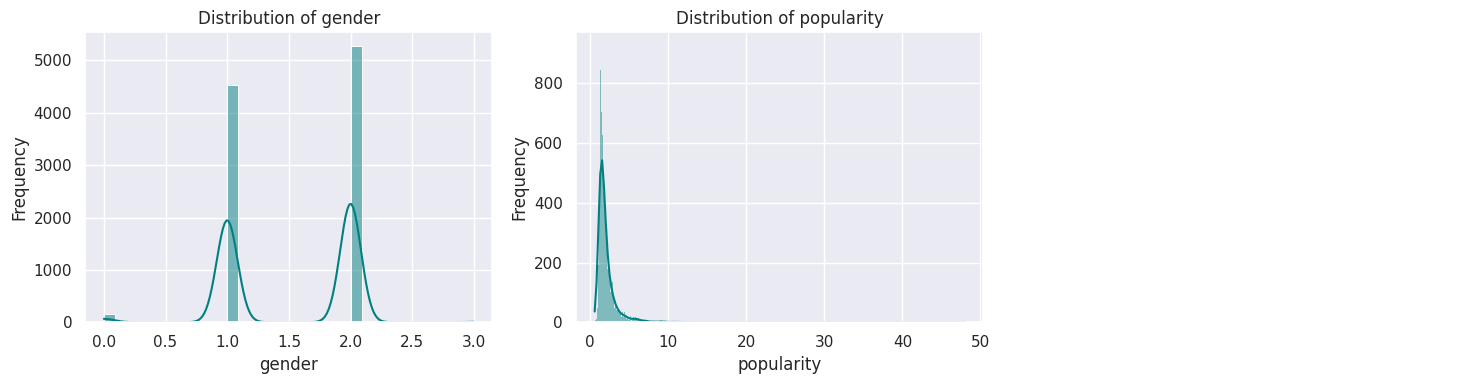

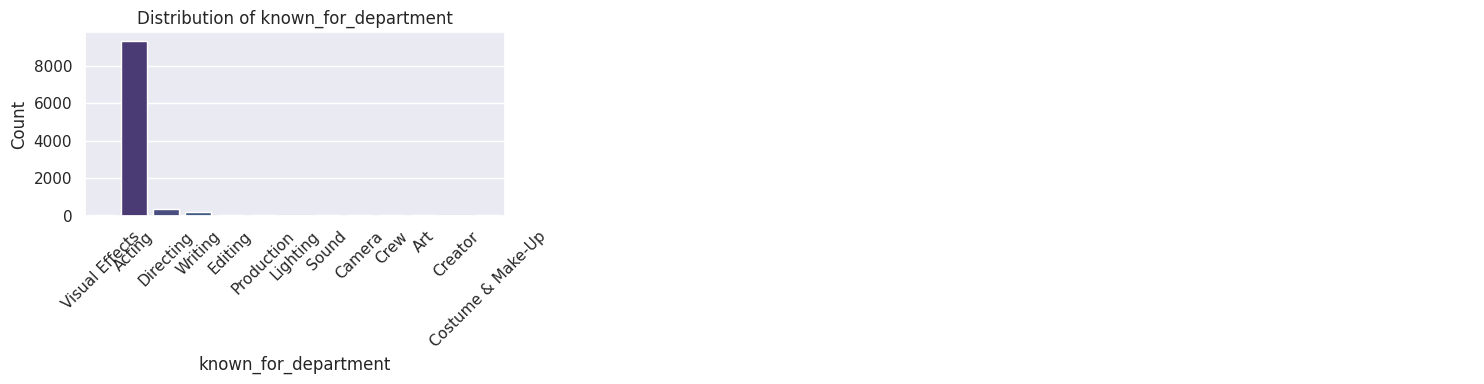

--- Categorical Value Counts ---

Value counts for known_for_department:
known_for_department
Acting               9320
Directing             329
Writing               174
Production             43
Sound                  27
Editing                18
Visual Effects         17
Crew                   16
Art                     8
Costume & Make-Up       8
Camera                  7
Lighting                5
Creator                 3
Name: count, dtype: int64


In [27]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

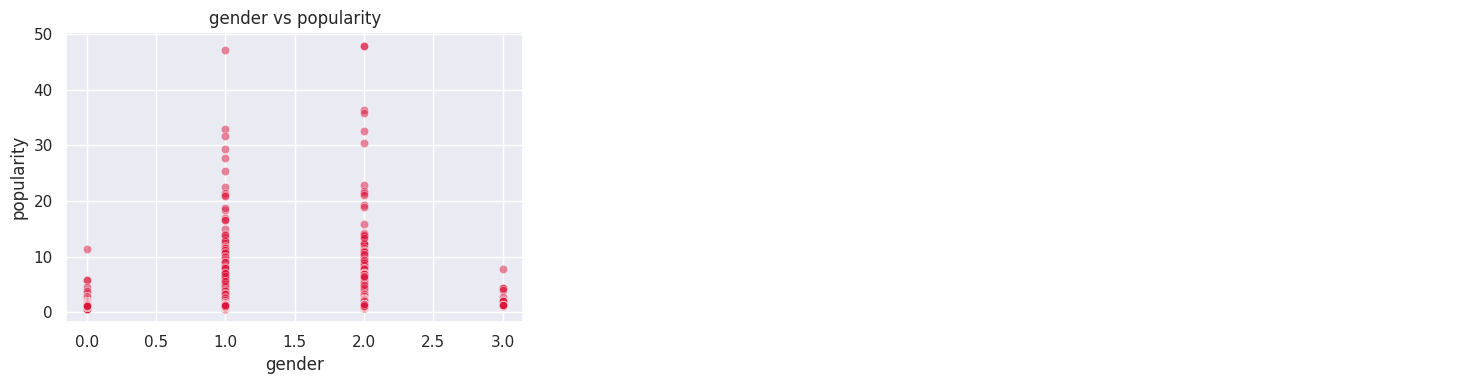

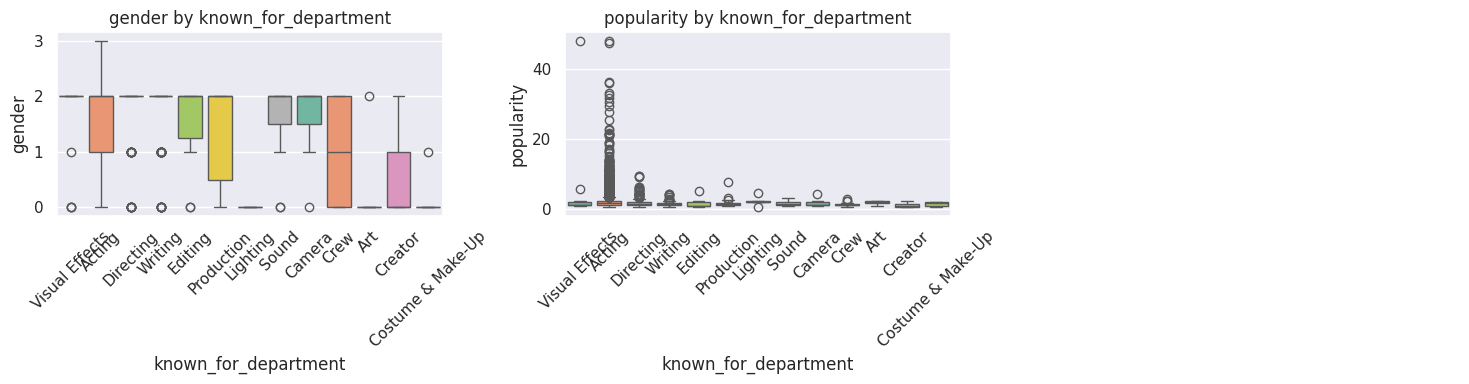

In [30]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a 1D array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson')
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a 1D array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a 1D array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: known_for_department...


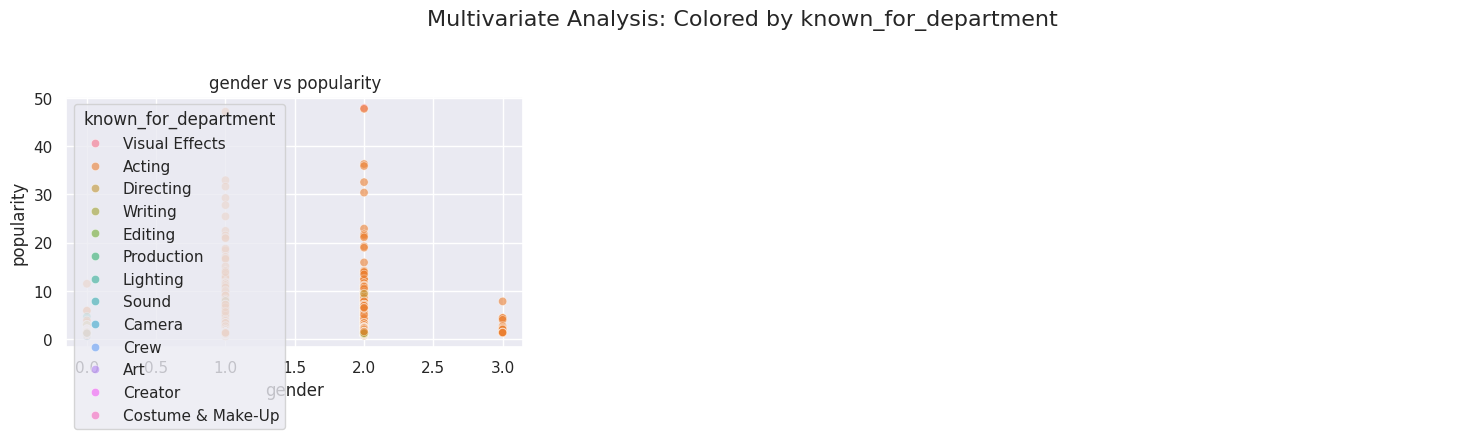

In [32]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 20)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure and axes
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))

        # Ensure axes is always a 1D array of Axes objects
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        else:
            axes = axes.flatten()

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

## Statistical Analysis: Hypothesis Testing

In [33]:
from scipy.stats import f_oneway

# Drop rows with null values in 'known_for_department' for accurate analysis
df_filtered = df.dropna(subset=['known_for_department'])

# Get unique departments
departments = df_filtered['known_for_department'].unique()

# Create a list of popularity scores for each department
popularity_by_department = [df_filtered[df_filtered['known_for_department'] == dept]['popularity'] for dept in departments]

# Perform ANOVA test
f_statistic, p_value = f_oneway(*popularity_by_department)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in popularity across different 'known_for_department' categories.")
else:
    print("\nConclusion: There is no statistically significant difference in popularity across different 'known_for_department' categories.")

ANOVA F-statistic: 4.72
ANOVA P-value: 0.000

Conclusion: There is a statistically significant difference in popularity across different 'known_for_department' categories.


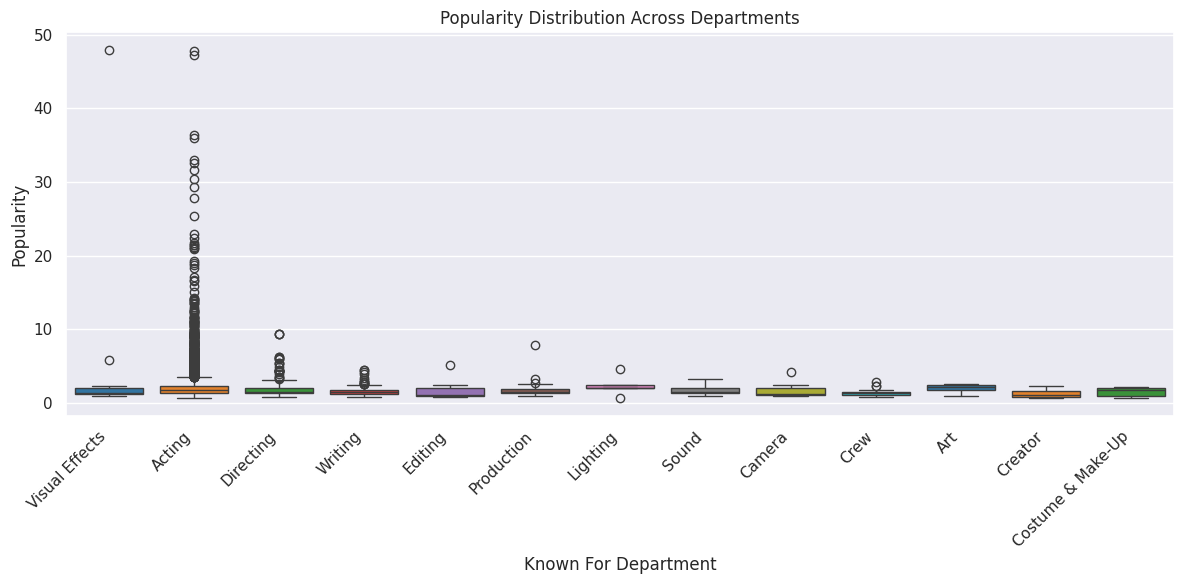

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='known_for_department', y='popularity', palette='tab10', hue='known_for_department', legend=False)
plt.title('Popularity Distribution Across Departments')
plt.xlabel('Known For Department')
plt.ylabel('Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2. Comparing Popularity Between Genders

In [34]:
from scipy.stats import ttest_ind

# Filter out gender '0' (unknown/non-binary) if we only want to compare 1 and 2
df_gender_filtered = df[df['gender'].isin([1, 2])]

# Separate popularity by gender
popularity_gender_1 = df_gender_filtered[df_gender_filtered['gender'] == 1]['popularity']
popularity_gender_2 = df_gender_filtered[df_gender_filtered['gender'] == 2]['popularity']

# Perform independent samples t-test
t_statistic, p_value_gender = ttest_ind(popularity_gender_1, popularity_gender_2, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value_gender:.3f}")

if p_value_gender < 0.05:
    print("\nConclusion: There is a statistically significant difference in popularity between gender 1 and gender 2.")
else:
    print("\nConclusion: There is no statistically significant difference in popularity between gender 1 and gender 2.")

T-statistic: 3.05
P-value: 0.002

Conclusion: There is a statistically significant difference in popularity between gender 1 and gender 2.


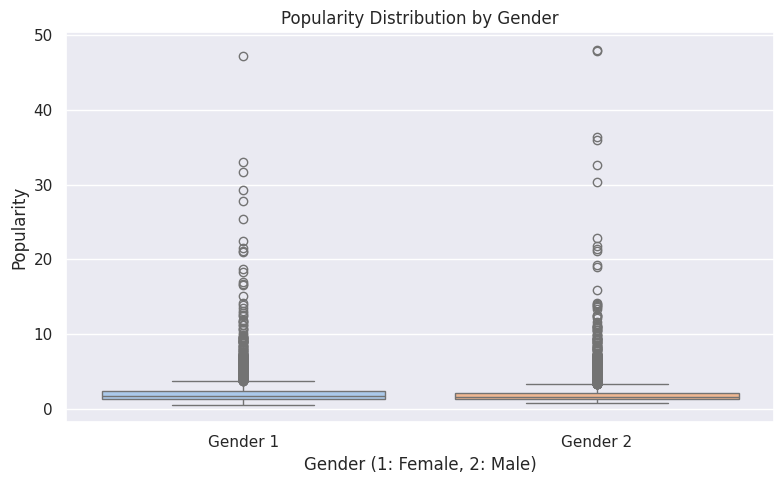

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gender_filtered, x='gender', y='popularity', palette='pastel', hue='gender', legend=False)
plt.title('Popularity Distribution by Gender')
plt.xlabel('Gender (1: Female, 2: Male)')
plt.ylabel('Popularity')
plt.xticks([0, 1], ['Gender 1', 'Gender 2']) # Assuming 1 and 2 are primary genders
plt.tight_layout()
plt.show()

### 3. Association Between `gender` and `known_for_department`


In [35]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['gender'], df['known_for_department'])

# Perform Chi-squared test
chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value_chi2:.3f}")
print(f"Degrees of Freedom: {dof}")

if p_value_chi2 < 0.05:
    print("\nConclusion: There is a statistically significant association between 'gender' and 'known_for_department'.")
else:
    print("\nConclusion: There is no statistically significant association between 'gender' and 'known_for_department'.")

Chi-squared statistic: 2027.20
P-value: 0.000
Degrees of Freedom: 36

Conclusion: There is a statistically significant association between 'gender' and 'known_for_department'.


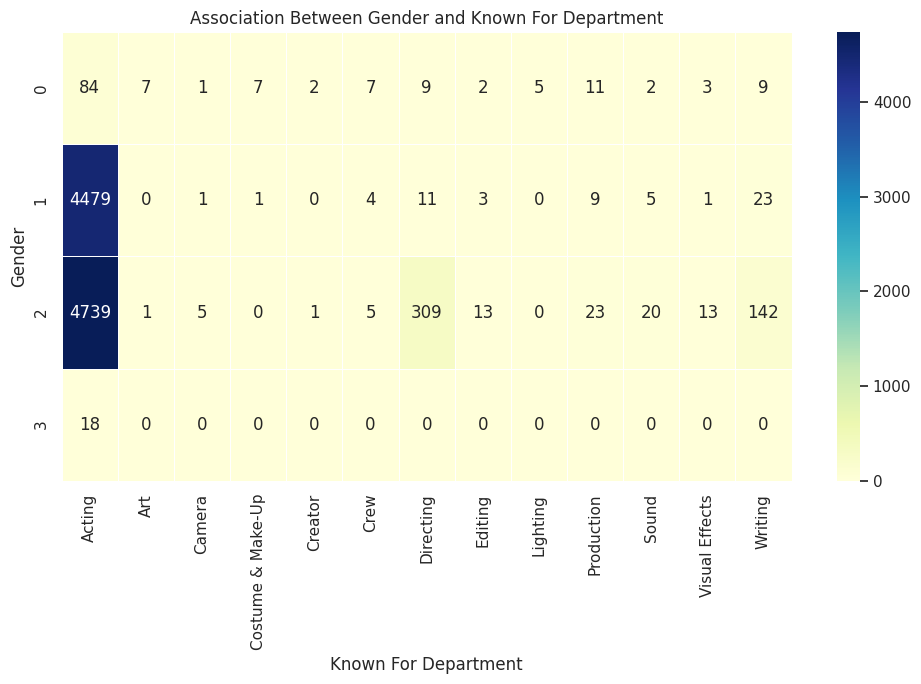

In [38]:
plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Association Between Gender and Known For Department')
plt.xlabel('Known For Department')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

## Feature Engineering

In [39]:
# 1. One-hot encode 'known_for_department'
df_encoded = pd.get_dummies(df, columns=['known_for_department'], prefix='department', drop_first=True)

# 2. One-hot encode 'gender' with more descriptive labels
# Mapping gender codes to labels
gender_mapping = {0: 'Gender_Unknown', 1: 'Gender_Female', 2: 'Gender_Male', 3: 'Gender_NonBinary'}
df_encoded['gender_label'] = df_encoded['gender'].map(gender_mapping)

df_encoded = pd.get_dummies(df_encoded, columns=['gender_label'], prefix='gender', drop_first=True)

# Dropping the original 'gender' column after encoding
df_encoded = df_encoded.drop(columns=['gender'])

# 3. Dropping 'original_name' as it's often redundant with 'name'
df_encoded = df_encoded.drop(columns=['original_name'])

# Displaying the updated DataFrame info and head
print("DataFrame after Feature Engineering:")
df_encoded.info()
display(df_encoded.head())

DataFrame after Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          9980 non-null   object 
 1   popularity                    9980 non-null   float64
 2   department_Art                9980 non-null   bool   
 3   department_Camera             9980 non-null   bool   
 4   department_Costume & Make-Up  9980 non-null   bool   
 5   department_Creator            9980 non-null   bool   
 6   department_Crew               9980 non-null   bool   
 7   department_Directing          9980 non-null   bool   
 8   department_Editing            9980 non-null   bool   
 9   department_Lighting           9980 non-null   bool   
 10  department_Production         9980 non-null   bool   
 11  department_Sound              9980 non-null   bool   
 12  department_Visual Effects

,name,popularity,department_Art,department_Camera,department_Costume & Make-Up,department_Creator,department_Crew,department_Directing,department_Editing,department_Lighting,department_Production,department_Sound,department_Visual Effects,department_Writing,gender_Gender_Male,gender_Gender_NonBinary,gender_Gender_Unknown
0,Eric Larson,47.9780,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,Robert Middlemass,47.8017,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,María Vaner,47.2016,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Carl Wharton,36.3365,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,Victor Moore,35.9181,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


## Visualizing Engineered Features

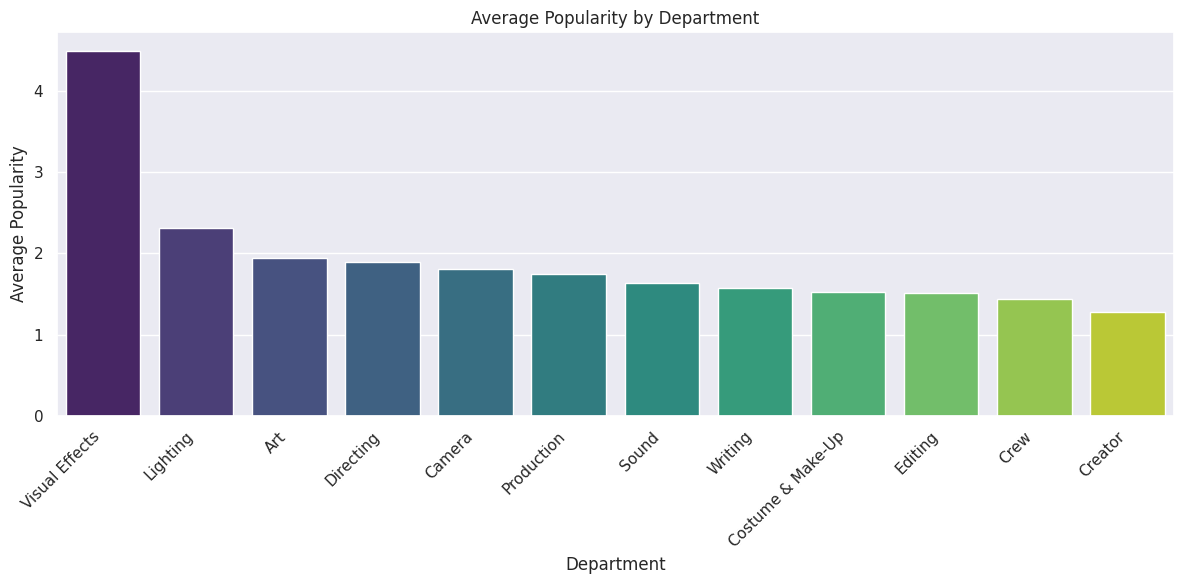

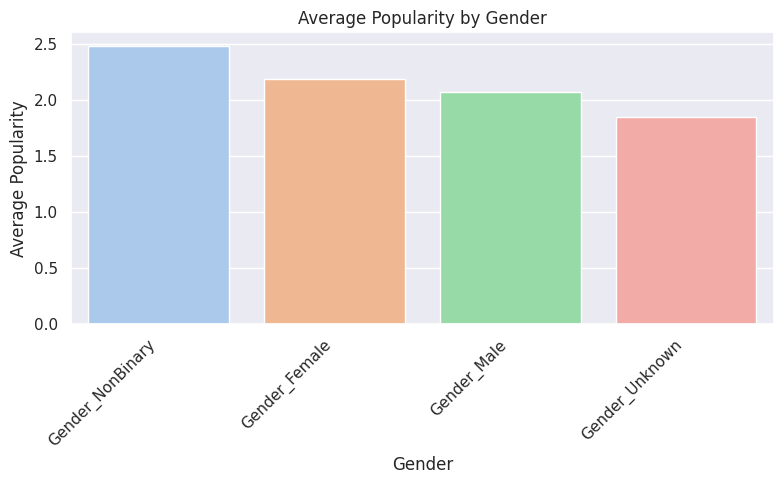

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Average Popularity by Department ---
department_cols = [col for col in df_encoded.columns if col.startswith('department_')]

department_popularity = []
for col in department_cols:
    department_name = col.replace('department_', '')
    avg_popularity = df_encoded[df_encoded[col]]['popularity'].mean()
    department_popularity.append({'department': department_name, 'avg_popularity': avg_popularity})

df_dept_popularity = pd.DataFrame(department_popularity).sort_values(by='avg_popularity', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='department', y='avg_popularity', data=df_dept_popularity, palette='viridis')
plt.title('Average Popularity by Department')
plt.xlabel('Department')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 2. Average Popularity by Gender ---
gender_cols = [col for col in df_encoded.columns if col.startswith('gender_')]

gender_popularity = []
# Include the 'Female' case by considering the absence of 'Male', 'NonBinary', 'Unknown'
# Assuming Gender_Female is the base case (not dropped by drop_first=True for gender_label)
# If 'gender_Gender_Male', 'gender_Gender_NonBinary', 'gender_Gender_Unknown' are False, it implies 'Female'

# Calculate for explicit gender columns
for col in gender_cols:
    gender_label = col.replace('gender_', '')
    if df_encoded[col].any(): # Only calculate if there are instances of this gender
        avg_popularity = df_encoded[df_encoded[col]]['popularity'].mean()
        gender_popularity.append({'gender': gender_label, 'avg_popularity': avg_popularity})

# Get popularity for 'Gender_Female' (where all other gender-encoded columns are False)
female_filter = ~df_encoded['gender_Gender_Male'] & \
                ~df_encoded['gender_Gender_NonBinary'] & \
                ~df_encoded['gender_Gender_Unknown']

if female_filter.any(): # Check if there are any 'Female' entries
    avg_popularity_female = df_encoded[female_filter]['popularity'].mean()
    gender_popularity.append({'gender': 'Gender_Female', 'avg_popularity': avg_popularity_female})

df_gender_popularity = pd.DataFrame(gender_popularity).sort_values(by='avg_popularity', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='avg_popularity', data=df_gender_popularity, palette='pastel')
plt.title('Average Popularity by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Machine Learning Modeling

Shape of X_train: (6982, 4)
Shape of X_test: (2993, 4)
Shape of y_train: (6982,)
Shape of y_test: (2993,)

Model Accuracy: 0.9014

Classification Report:
                   precision    recall  f1-score   support

           Acting       0.96      0.94      0.95      2797
              Art       0.00      0.00      0.00         2
           Camera       0.50      0.50      0.50         2
Costume & Make-Up       0.67      1.00      0.80         2
          Creator       0.00      0.00      0.00         1
             Crew       0.00      0.00      0.00         5
        Directing       0.29      0.38      0.33        99
          Editing       0.22      0.40      0.29         5
         Lighting       0.00      0.00      0.00         2
       Production       0.39      0.54      0.45        13
            Sound       0.20      0.38      0.26         8
   Visual Effects       0.20      0.20      0.20         5
          Writing       0.29      0.42      0.34        52

         accuracy 

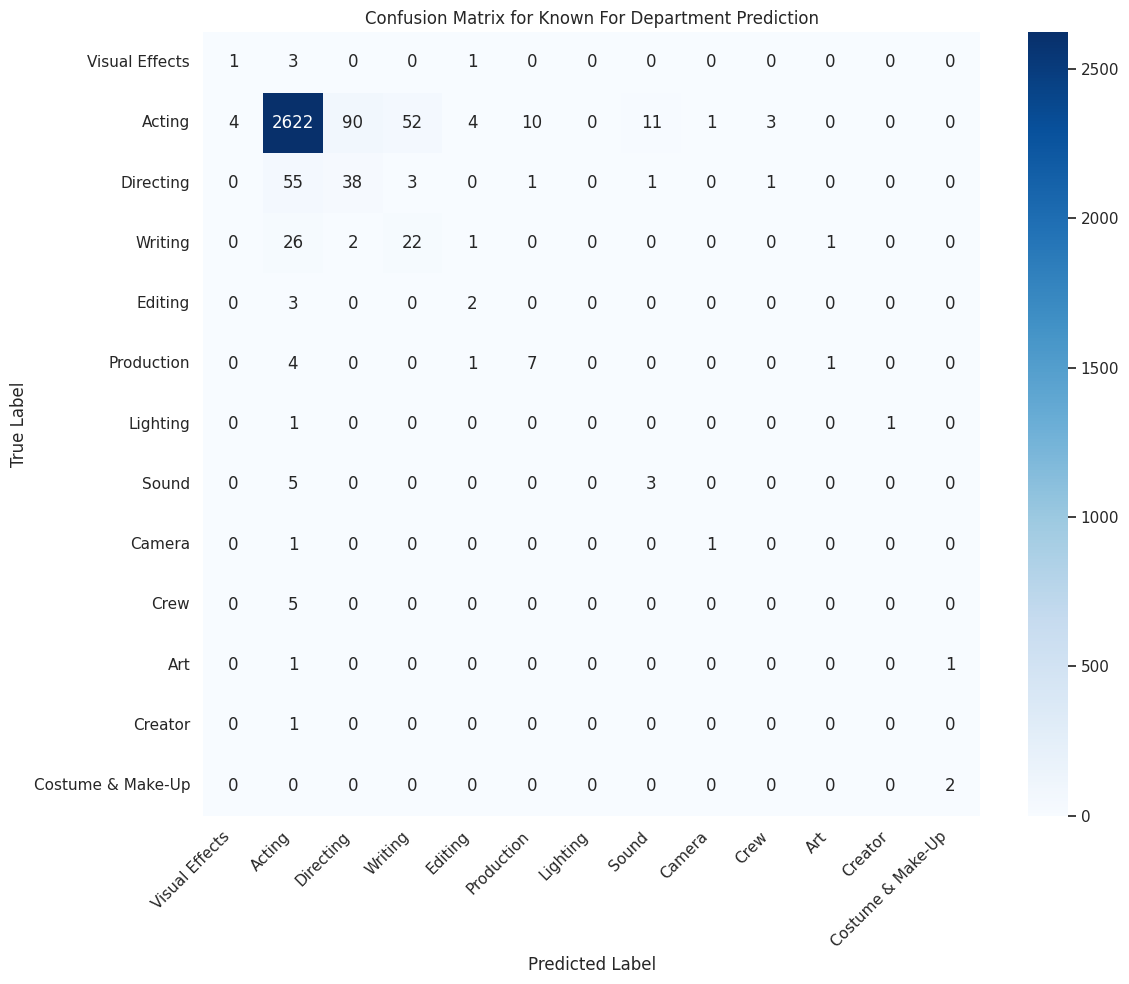

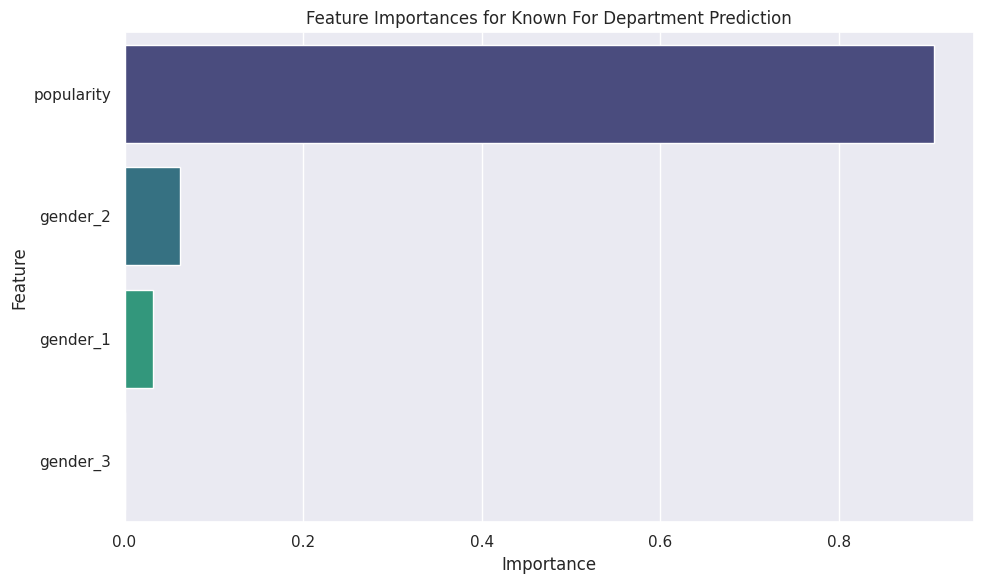

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Prepare Data for ML ---
# Start with the original df and drop rows where 'known_for_department' is NaN
df_ml_prep = df.dropna(subset=['known_for_department']).copy()

# Define target variable (y)
y = df_ml_prep['known_for_department']

# Define feature variables (X)
# We'll use 'popularity' and one-hot encode 'gender'
X = df_ml_prep[['popularity', 'gender']]
X = pd.get_dummies(X, columns=['gender'], prefix='gender', drop_first=True) # drop_first for multicollinearity

# --- 2. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Using stratify=y to ensure that the proportion of target classes is similar in train and test sets.

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# --- 3. Train a Classification Model (Random Forest) ---
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
# class_weight='balanced' is good for imbalanced classes, which might be the case for departments.
model.fit(X_train, y_train)

# --- 4. Evaluate Model ---
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Visualize Results: Confusion Matrix ---
# Ensure all unique labels from the target are used for the confusion matrix to avoid errors
cm_labels = y.unique()
cm = confusion_matrix(y_test, y_pred, labels=cm_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels)
plt.title('Confusion Matrix for Known For Department Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 6. Feature Importance ---
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances for Known For Department Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Thank You